# Notebook Description

Purpose of this notebook is to compare Machine Learning Models implemented in ML_baselines.py with in-depth analysis to detect the best performing baseline model.

Workflow:
1. Use report_multiclass.md report generated by running the ML_baselines.py script to detect setting resulting in the best F1 score (weighted) for each of the implemented models:
    - Naive Bayas
    - Support Vector Machine (SVM)
    - Logistic Regression (BoW)
    - Logistic Regression (TFIDF)
2. Retrain each of the models on full training data (include both data.csv and train.csv) + Create predictions using test set
3. Evaluate performance of each of the models on test set and compare the results

# Load packages

In [35]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
from scripts.ML_baselines import encode_target, preprocess_text, extract_features
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from matplotlib.gridspec import GridSpec
import ast
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_fscore_support


# Data Loading

In [36]:
# training set
df_train = pd.read_csv("../data/splits/train.csv")
df_val = pd.read_csv("../data/splits/val.csv")
df_full_train = pd.concat([df_train, df_val], ignore_index=True)
# test set
df_test = pd.read_csv("../data/splits/test.csv")
# select relevant columns
df_full_train = df_full_train[["sentence", "word_order", "language", "period"]]
df_test = df_test[["sentence", "word_order", "language", "period"]]

Note: while only variables "sentence" and "word_order" will be used for model training ("sentence" being a feature and "word_order" being a target variable), we have included additional 2 columns (language, period) for more in detail analysis of performance (e.g. to explore if model performs different across different languages).

# 1. Retrieve best performing model (F1 weighted score) on CV by reading report file

In [37]:
# path to report file
report_path = Path("../reports/report_multiclass.md")
# read report content
text = report_path.read_text()
# extract validation results table using regex
pattern = r"## VALIDATION RESULTS\n\n(.*?)\n\n---"
match = re.search(pattern, text, re.S)
table_md = match.group(1)
# load table into DataFrame
df_CV_results = pd.read_csv(
    StringIO(table_md),
    sep="|",
    engine="python",
    skiprows=[1] 
).dropna(axis=1, how="all")
# clean column names
df_CV_results.columns = df_CV_results.columns.str.strip()
# clean values in DataFrame
df_CV_results = df_CV_results.map(lambda x: x.strip() if isinstance(x, str) else x)
# remove columns that are not needed
df_CV_results = df_CV_results[["feature", "model", "best_params"]]
# convert string representation of dict back to dict
df_CV_results["best_params"] = df_CV_results["best_params"].apply(ast.literal_eval)
# display the DataFrame
df_CV_results


,feature,model,best_params
0,TFIDF,SVM,{'C': 1.0}
1,BoW,LogisticRegression,"{'C': 1.0, 'penalty': 'l2', 'solver': 'saga'}"
2,TFIDF,LogisticRegression,"{'C': 5.0, 'penalty': 'l2', 'solver': 'lbfgs'}"
3,BoW,NaiveBayes,{'alpha': 1.0}


# 2. Retraining the models + predict the target variable

## 2.1 Preprocessing

In [38]:
# preprocess sentences
X_full_train = df_full_train["sentence"].apply(preprocess_text)
X_test = df_test["sentence"].apply(preprocess_text)
# select target variable (no encoding)
y_full_train = df_full_train["word_order"]
y_test = df_test["word_order"]

In [39]:
X_full_train.head()

0    die berliner afd trifft sich nicht an diesem w...
1    da jede investition in berlin aber steuern gen...
2    this is just another sign that people are not ...
3    лучше держаться подальше от озера или речки ка...
4    ein hütchen mit federn die armbrust über der s...
Name: sentence, dtype: object

In [40]:
y_full_train.head()

0           SVO
1    INCOMPLETE
2    INCOMPLETE
3    INCOMPLETE
4    INCOMPLETE
Name: word_order, dtype: object

## 2.2 Training the models on full training set (combined train.csv and val.csv) + predict target variable on test set (test.csv)

In [41]:
# helper function to get model instance
def get_model(model_name: str, params: dict):
    if model_name == "LogisticRegression":
        return LogisticRegression(**params, max_iter=1000)
    elif model_name == "SVM":
        return LinearSVC(**params)
    elif model_name == "NaiveBayes":
        return MultinomialNB(**params)

In [42]:
predictions = {}
training_times = {}

for row in df_CV_results.itertuples(index=False):

    feature = row.feature.lower()
    model_name = row.model
    params = row.best_params

    key = f"{model_name}_{feature}"

    print(f"\nTraining model: {model_name}")
    print(f"Feature extraction method: {feature}")
    print(f"Parameters: {params}")

    # Extract features
    X_train_vec, X_test_vec = extract_features(
        X_full_train,
        X_test,
        method=feature
    )

    # Build model
    model = get_model(model_name, params)

    # Train model on full training data
    start = time.time()
    model.fit(X_train_vec, y_full_train)
    training_times[key] = round(time.time() - start, 3)

    print(f"Training time: {training_times[key]} seconds")

    # Predict target variable
    y_pred = model.predict(X_test_vec)

    # Save results
    predictions[key] = y_pred



Training model: SVM
Feature extraction method: tfidf
Parameters: {'C': 1.0}
Training time: 9.547 seconds

Training model: LogisticRegression
Feature extraction method: bow
Parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'saga'}
Training time: 109.071 seconds

Training model: LogisticRegression
Feature extraction method: tfidf
Parameters: {'C': 5.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Training time: 134.193 seconds

Training model: NaiveBayes
Feature extraction method: bow
Parameters: {'alpha': 1.0}
Training time: 0.46 seconds


# 3. Performance evaluation

## 3.0 Class distribution

In [43]:
def class_percentages(y, sort=True):
    """
    Returns a DataFrame with count and percentage per class.
    """
    counts = pd.Series(y).value_counts(sort=False)

    if sort:
        counts = counts.sort_values(ascending=False)

    percentages = counts / counts.sum() * 100

    df = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    return df
class_dist = class_percentages(y_test)
print(class_dist)


            count  percentage
word_order                   
SV_only     11155       48.23
INCOMPLETE   5353       23.14
SVO          4055       17.53
SOV           885        3.83
VO_only       659        2.85
VSO           544        2.35
OVS           180        0.78
OSV           153        0.66
VOS           145        0.63


## 3.1 Confusion matrix

In [44]:
# Compute and store confusion matrices
conf_matrices = {}
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm

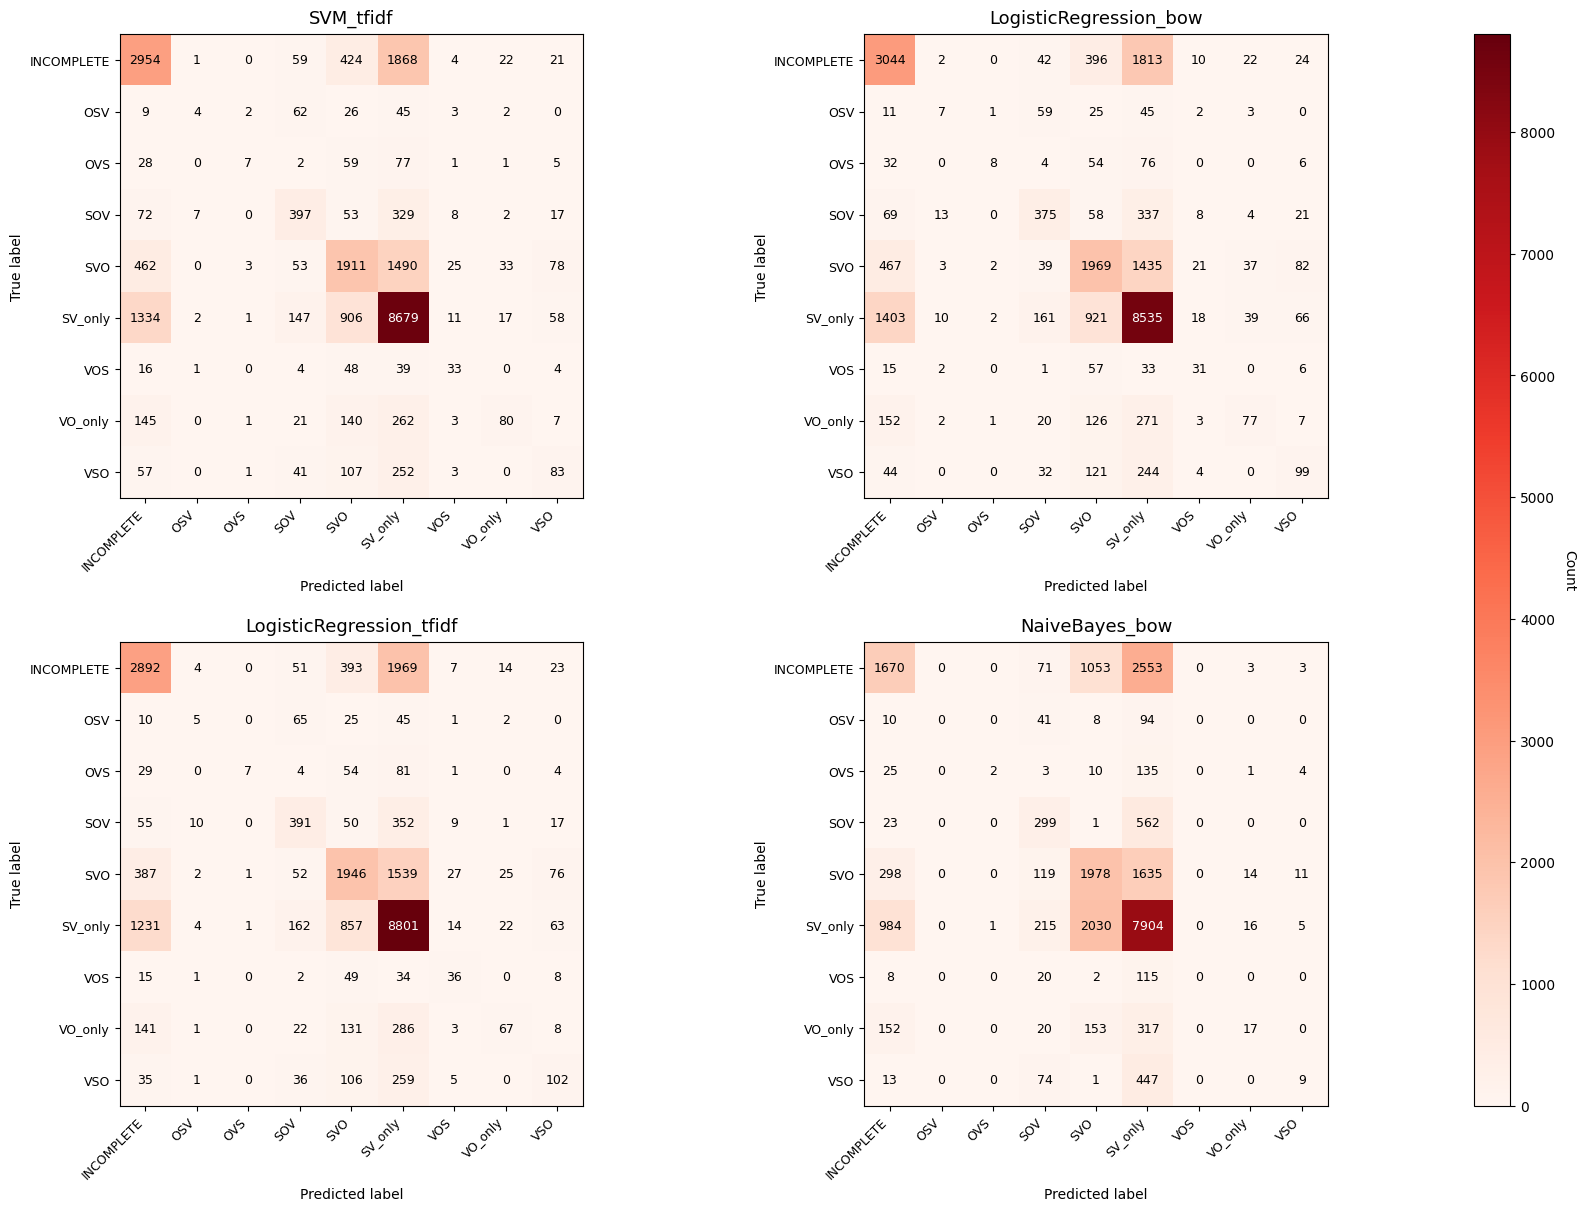

In [45]:
labels = sorted(np.unique(y_test))
n_classes = len(labels)

fig = plt.figure(figsize=(16, 12), constrained_layout=True)

gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 0.05])

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

cax = fig.add_subplot(gs[:, 2])

global_max = max(
    confusion_matrix(y_test, y_pred, labels=labels).max()
    for y_pred in predictions.values()
)

for ax, (name, y_pred) in zip(axes, predictions.items()):

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    im = ax.imshow(
        cm,
        cmap="Reds",
        vmin=0,
        vmax=global_max
    )

    ax.set_title(name, fontsize=13, pad=8)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    thresh = global_max * 0.5
    for i in range(n_classes):
        for j in range(n_classes):
            val = cm[i, j]
            ax.text(
                j, i, f"{val}",
                ha="center", va="center",
                fontsize=9,
                color="white" if val > thresh else "black"
            )

cb = fig.colorbar(im, cax=cax)
cb.set_label("Count", rotation=270, labelpad=15)

plt.show()


Based on the confusion matrices, we draw the following conclusions:

1. All models display very similar prediction behavior and error patterns, as evidenced by the comparable structure of their confusion matrices.
2. The dataset is strongly imbalanced: SV_only is the dominant class (48.23%), followed by INCOMPLETE (23.14%) and SVO (17.53%), while all remaining classes each account for less than 4% of the data.
3. The most noticeable source of error across all models is confusion between SV_only, SVO, and INCOMPLETE. Sentences belonging to these classes are frequently misclassified as one another.
4. Misclassifications involving the remaining word-order classes (OSV, OVS, VOS, VSO, SOV, VO_only) are comparatively limited and typically result in predictions into one of the dominant classes rather than into another rare category.
5. Overall, the results indicate that bag-of-words and TF–IDF representations are effective for identifying dominant sentence patterns but are less effective at distinguishing closely related syntactic structures.


### Model Comparison Summary

1. Naive Bayes (BoW) attains slightly higher recall for the SVO class; however, this gain is marginal and comes at the expense of substantially reduced recall for other word-order categories, resulting in the weakest overall balanced performance.
2. On a first sight, it is hard to distinguish detailed differences between the models. For that reason, we perform per class and overall quantitative analysis to determine the best model.


Before making final decision, lets compute additional metrics for quantitatice comparison.

## 3.2 Quantitative Analysis

### 3.2.1 Per Class Analysis

In [46]:
labels = sorted(np.unique(y_test))
rows = []
for model_name, y_pred in predictions.items():
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=labels,
        zero_division=0
    )
    for cls, p, r, f, s in zip(labels, precision, recall, f1, support):
        rows.append({
            "model": model_name,
            "class": cls,
            "precision": p,
            "recall": r,
            "f1": f,
            "misclassification_rate": 1 - r,
        })
df_per_class_metrics = (
    pd.DataFrame(rows)
    .set_index(["model", "class"])
    .round(4)
)
df_per_class_metrics

precision  recall      f1  \
model                    class                                   
SVM_tfidf                INCOMPLETE     0.5818  0.5518  0.5664   
                         OSV            0.2667  0.0261  0.0476   
                         OVS            0.4667  0.0389  0.0718   
                         SOV            0.5051  0.4486  0.4752   
                         SVO            0.5201  0.4713  0.4945   
                         SV_only        0.6655  0.7780  0.7174   
                         VOS            0.3626  0.2276  0.2797   
                         VO_only        0.5096  0.1214  0.1961   
                         VSO            0.3040  0.1526  0.2032   
LogisticRegression_bow   INCOMPLETE     0.5812  0.5687  0.5749   
                         OSV            0.1795  0.0458  0.0729   
                         OVS            0.5714  0.0444  0.0825   
                         SOV            0.5116  0.4237  0.4635   
                         SVO            0.5283  0.4856  0.5060   
                         SV_only        0.6674  0.7651  0.7129   
                         VOS            0.3196  0.2138  0.2562   
                         VO_only        0.4231  0.1168  0.1831   
                         VSO            0.3183  0.1820  0.2316   
LogisticRegression_tfidf INCOMPLETE     0.6031  0.5403  0.5700   
                         OSV            0.1786  0.0327  0.0552   
                         OVS            0.7778  0.0389  0.0741   
                         SOV            0.4981  0.4418  0.4683   
                         SVO            0.5389  0.4799  0.5077   
                         SV_only        0.6585  0.7890  0.7178   
                         VOS            0.3495  0.2483  0.2903   
                         VO_only        0.5115  0.1017  0.1696   
                         VSO            0.3389  0.1875  0.2414   
NaiveBayes_bow           INCOMPLETE     0.5247  0.3120  0.3913   
                         OSV            0.0000  0.0000  0.0000   
                         OVS            0.6667  0.0111  0.0219   
                         SOV            0.3469  0.3379  0.3423   
                         SVO            0.3778  0.4878  0.4258   
                         SV_only        0.5743  0.7086  0.6344   
                         VOS            0.0000  0.0000  0.0000   
                         VO_only        0.3333  0.0258  0.0479   
                         VSO            0.2812  0.0165  0.0312   

                                     misclassification_rate  
model                    class                               
SVM_tfidf                INCOMPLETE                  0.4482  
                         OSV                         0.9739  
                         OVS                         0.9611  
                         SOV                         0.5514  
                         SVO                         0.5287  
                         SV_only                     0.2220  
                         VOS                         0.7724  
                         VO_only                     0.8786  
                         VSO                         0.8474  
LogisticRegression_bow   INCOMPLETE                  0.4313  
                         OSV                         0.9542  
                         OVS                         0.9556  
                         SOV                         0.5763  
                         SVO                         0.5144  
                         SV_only                     0.2349  
                         VOS                         0.7862  
                         VO_only                     0.8832  
                         VSO                         0.8180  
LogisticRegression_tfidf INCOMPLETE                  0.4597  
                         OSV                         0.9673  
                         OVS                         0.9611  
                         SOV                         0.5582  
                         SVO            


### Model Comparison Summary
1. Per-class performance is strongly class-dependent
2. SV_only is the most reliably predicted class
3. SVO performance differences across models are marginal
4. Excluding Naive Bayes, the remaining three models exhibit only marginal differences in per-class precision and recall. No model consistently outperforms the others across all word-order categories. Consequently, final model selection is based primarily on overall performance metrics, in particular balanced accuracy and macro-averaged F1 score.


### 3.2.2 Overall

In [47]:
metrics = []

for name, y_pred in predictions.items():

    metrics.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    })

df_metrics = pd.DataFrame(metrics).set_index("model").round(4)
df_metrics


,accuracy,balanced_accuracy,f1_weighted,f1_macro,precision_macro,recall_macro
model,,,,,,
SVM_tfidf,0.6117,0.3129,0.5950,0.3391,0.4647,0.3129
LogisticRegression_bow,0.6116,0.3162,0.5967,0.3426,0.4556,0.3162
LogisticRegression_tfidf,0.6160,0.3178,0.5983,0.3438,0.4950,0.3178
NaiveBayes_bow,0.5136,0.2111,0.4866,0.2105,0.3450,0.2111


Again, we observe that Naive Bayes consistently performs worst across all metrics and is therefore excluded.

Given the strong class imbalance and the fact that different word-order categories are linguistically meaningful, balanced accuracy is selected as the primary evaluation criterion to ensure fair treatment of all classes.

Based on **balanced accuracy**, Logistic Regression with TF–IDF is selected as the final baseline model. In addition, it also achieves the highest macro-averaged precision, recall, and F1 score among the evaluated models.

Therefore, **Logistic Regression with TF–IDF** is selected as the baseline model due to its balanced performance across classes and its consistent behavior across evaluation metrics.